In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


df = pd.read_csv(
    "/Users/mmadando/Downloads/data_banknote_authentication.txt",
    header=None
)

df.columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nSTATISTICS")
print(df.describe())

df.hist(figsize=(12, 8))
plt.suptitle("Feature Histograms")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="variance",
    y="skewness",
    hue="class"
)
plt.title("Variance vs Skewness")
plt.show()


plt.figure(figsize=(10, 6))
df.drop("class", axis=1).boxplot()
plt.title("Feature Boxplots")
plt.show()


X = df.drop("class", axis=1).values
y = df["class"].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAIN SIZE:", len(X_train))
print("TEST SIZE:", len(X_test))


class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=50):
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = 0

        self.errors = []

        self.weight_history = []
        self.bias_history = []

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):

        n_features = X.shape[1]

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                linear_output = np.dot(xi, self.weights) + self.bias

                prediction = self.activation(linear_output)

                update = self.learning_rate * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)

            self.weight_history.append(
                self.weights.copy()
            )

            self.bias_history.append(
                self.bias
            )

            print(
                f"Epoch {epoch+1:02d} | Errors = {errors}"
            )

    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        return self.activation(linear_output)


perceptron = Perceptron(
    learning_rate=0.01,
    epochs=50
)

perceptron.fit(
    X_train,
    y_train
)



y_pred = perceptron.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nFINAL WEIGHTS")
print(perceptron.weights)

print("\nFINAL BIAS")
print(perceptron.bias)

print("\nPERFORMANCE")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nCONFUSION MATRIX")
print(cm)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(perceptron.errors)+1),
    perceptron.errors,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.title("Training Error vs Epoch")
plt.grid(True)
plt.show()

weights = np.array(
    perceptron.weight_history
)

plt.figure(figsize=(10, 6))

for i in range(weights.shape[1]):
    plt.plot(
        range(1, len(weights)+1),
        weights[:, i],
        label=f"W{i+1}"
    )

plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(perceptron.bias_history)+1),
    perceptron.bias_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias Evolution")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

learning_rates = [
    0.001,
    0.01,
    0.1
]

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=50
    )

    model.fit(
        X_train,
        y_train
    )

    plt.plot(
        range(1, len(model.errors)+1),
        model.errors,
        label=f"LR={lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)

plt.show()



epoch_table = pd.DataFrame({
    "Epoch":
    range(
        1,
        len(perceptron.errors)+1
    ),

    "Errors":
    perceptron.errors,

    "Bias":
    perceptron.bias_history
})

print("\nEPOCH WISE LEARNING")
print(epoch_table)

summary = pd.DataFrame({

    "Metric": [
        "Dataset Size",
        "Train/Test Split",
        "Learning Rate",
        "Epochs",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value": [
        len(df),
        "80/20",
        0.01,
        50,
        round(accuracy,4),
        round(precision,4),
        round(recall,4),
        round(f1,4)
    ]
})

print("\nTRAINING SUMMARY")
print(summary)


OR GATE

Epoch 1

Update 1
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [0. 0.]
Bias: -0.1

Update 2
Input: [0 1]
Target: 1
Prediction: 0
Error: 1
Weights: [0.  0.1]
Bias: 0.0

Epoch 2

Update 3
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [0.  0.1]
Bias: -0.1

Update 4
Input: [1 0]
Target: 1
Prediction: 0
Error: 1
Weights: [0.1 0.1]
Bias: 0.0

Epoch 3

Update 5
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [0.1 0.1]
Bias: -0.1

Epoch 4

Converged!

Final Weights = [0.1 0.1]
Final Bias = -0.1


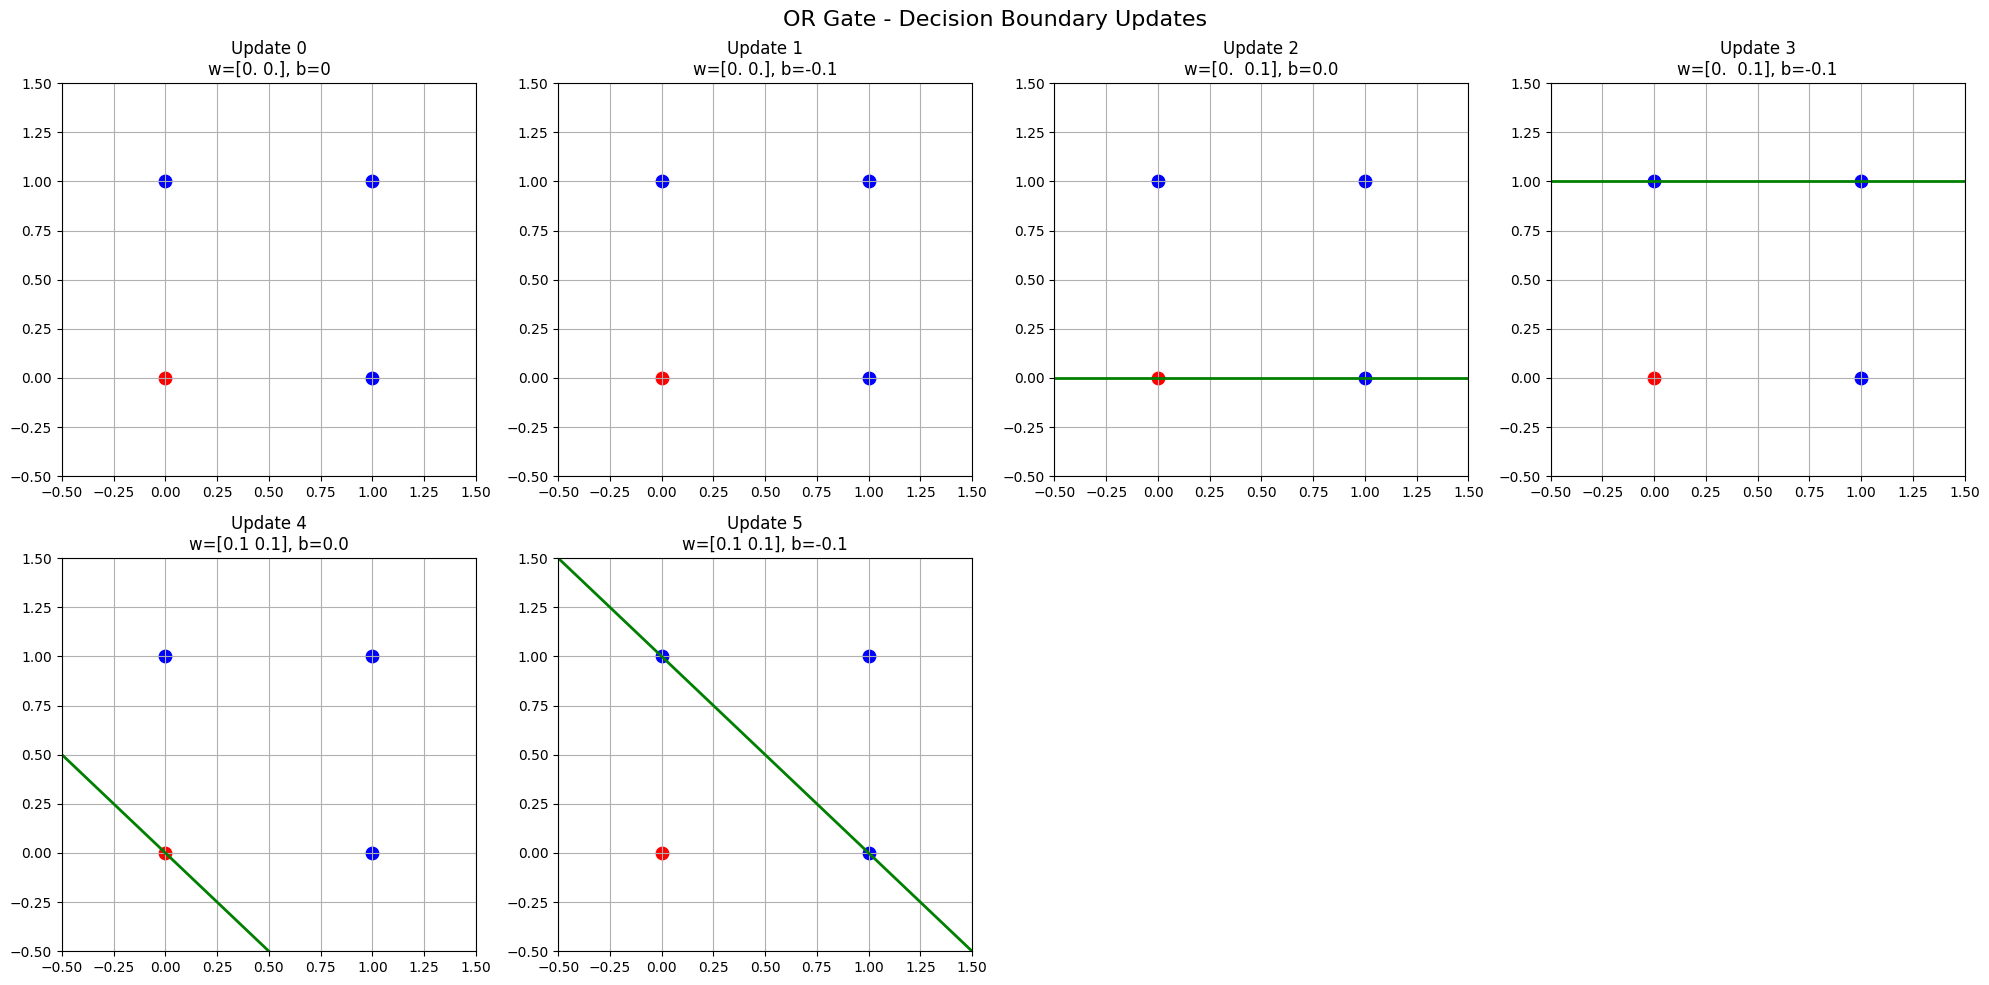


AND GATE

Epoch 1

Update 1
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [0. 0.]
Bias: -0.1

Update 2
Input: [1 1]
Target: 1
Prediction: 0
Error: 1
Weights: [0.1 0.1]
Bias: 0.0

Epoch 2

Update 3
Input: [0 0]
Target: 0
Prediction: 1
Error: -1
Weights: [0.1 0.1]
Bias: -0.1

Update 4
Input: [0 1]
Target: 0
Prediction: 1
Error: -1
Weights: [0.1 0. ]
Bias: -0.2

Update 5
Input: [1 1]
Target: 1
Prediction: 0
Error: 1
Weights: [0.2 0.1]
Bias: -0.1

Epoch 3

Update 6
Input: [0 1]
Target: 0
Prediction: 1
Error: -1
Weights: [0.2 0. ]
Bias: -0.2

Update 7
Input: [1 0]
Target: 0
Prediction: 1
Error: -1
Weights: [0.1 0. ]
Bias: -0.30000000000000004

Update 8
Input: [1 1]
Target: 1
Prediction: 0
Error: 1
Weights: [0.2 0.1]
Bias: -0.20000000000000004

Epoch 4

Converged!

Final Weights = [0.2 0.1]
Final Bias = -0.20000000000000004


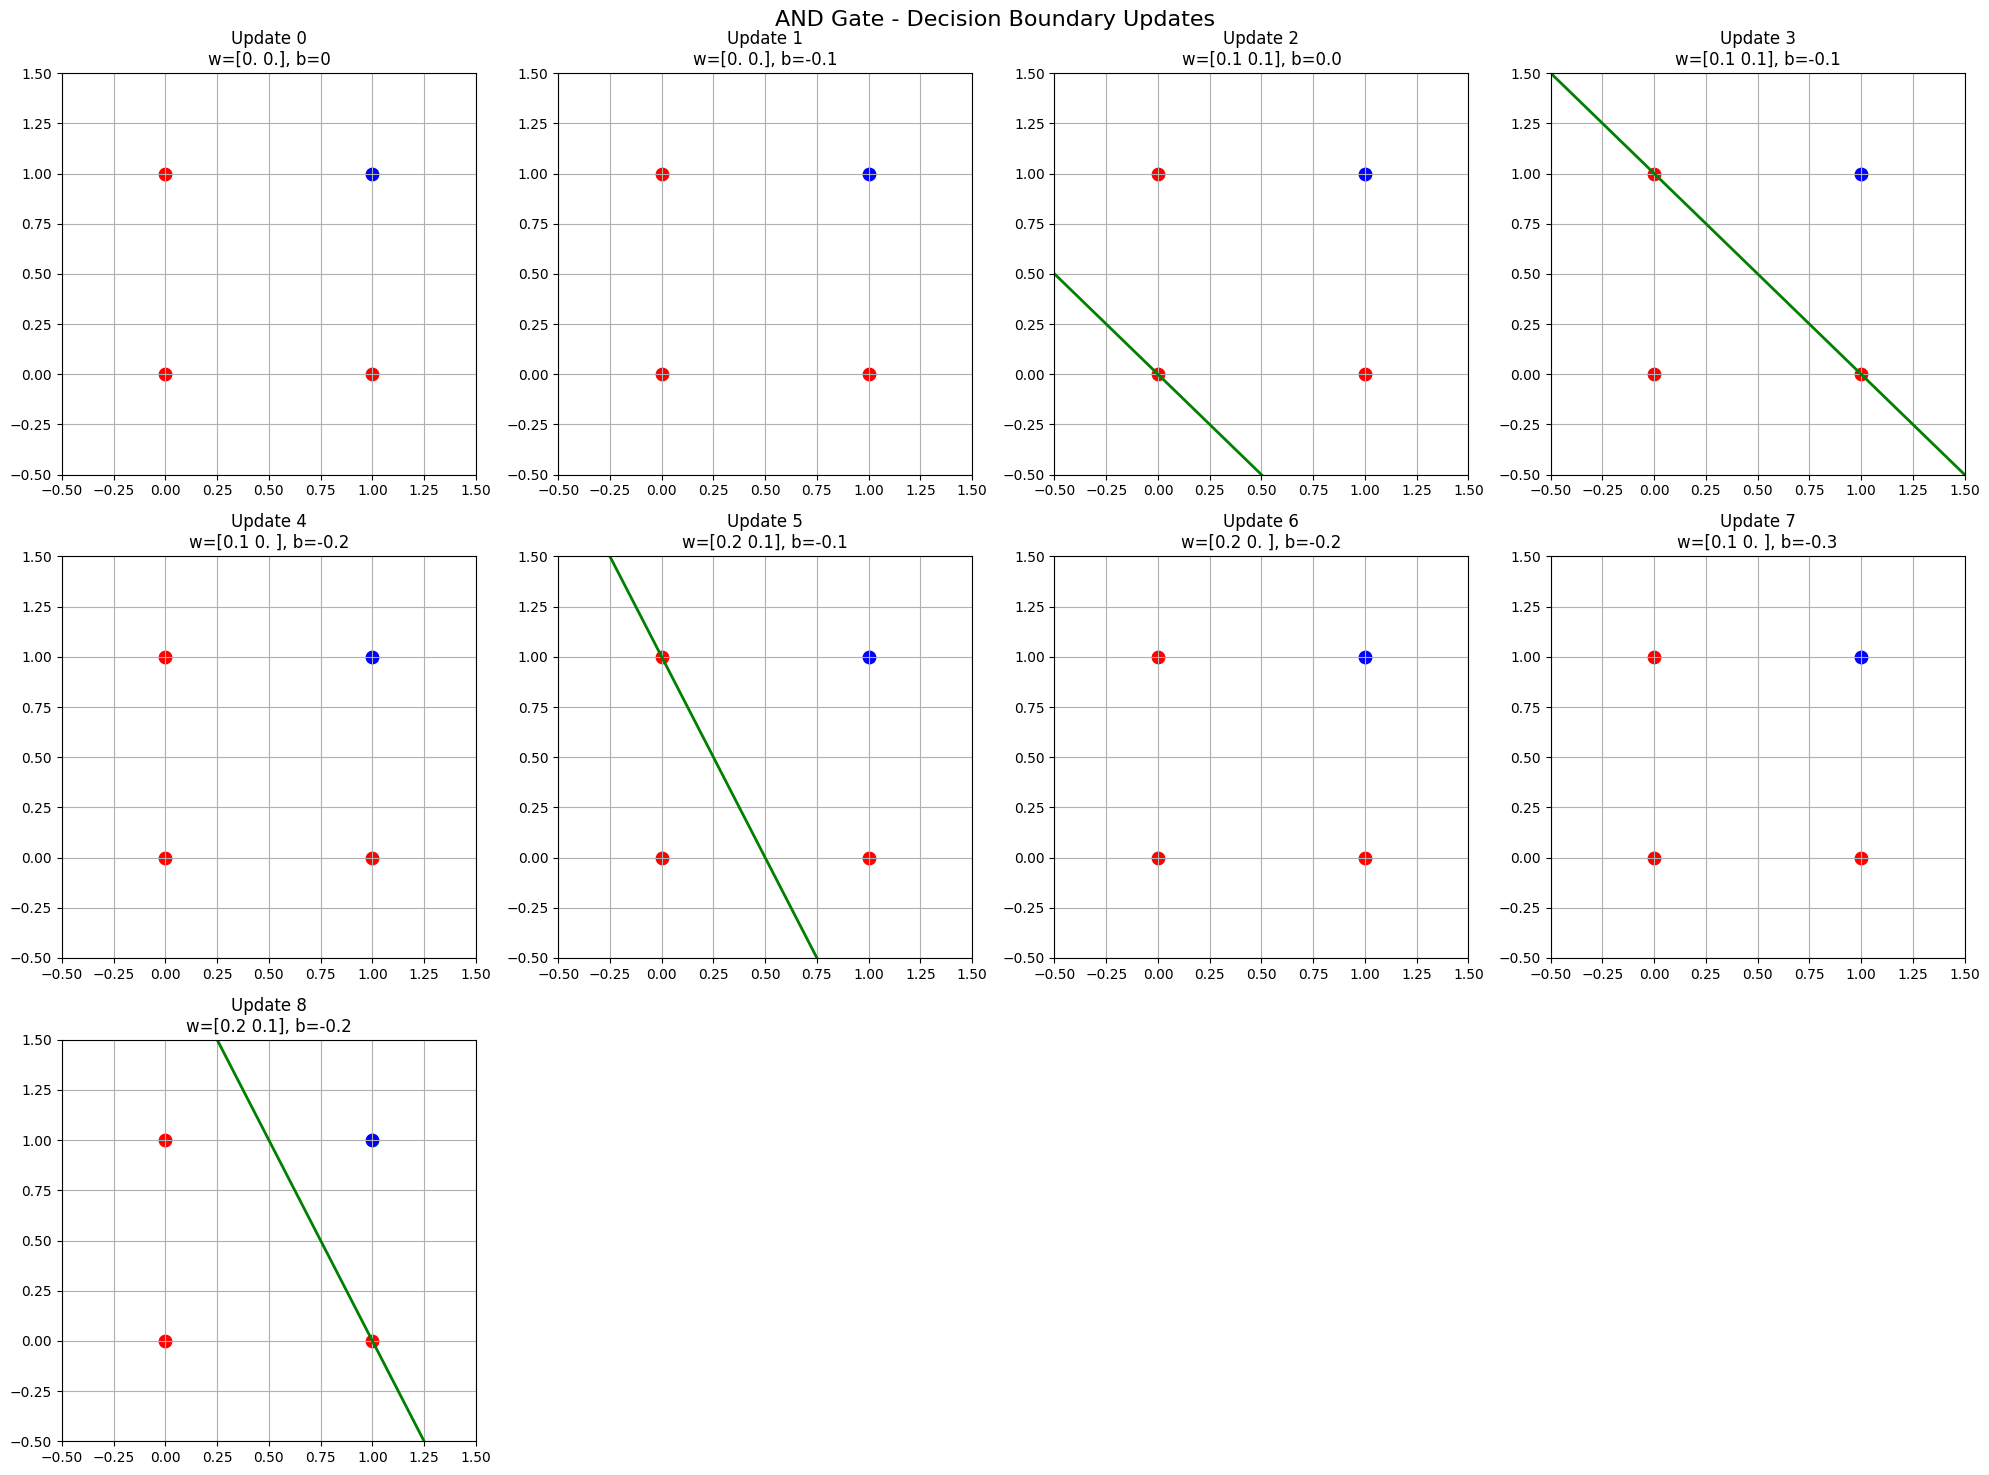


NOT GATE

Epoch 1

Update 1
Input: [1]
Target: 0
Prediction: 1
Error: -1
Weights: [-0.1]
Bias: -0.1

Epoch 2

Update 2
Input: [0]
Target: 1
Prediction: 0
Error: 1
Weights: [-0.1]
Bias: 0.0

Epoch 3

Converged!

Final Weights = [-0.1]
Final Bias = 0.0


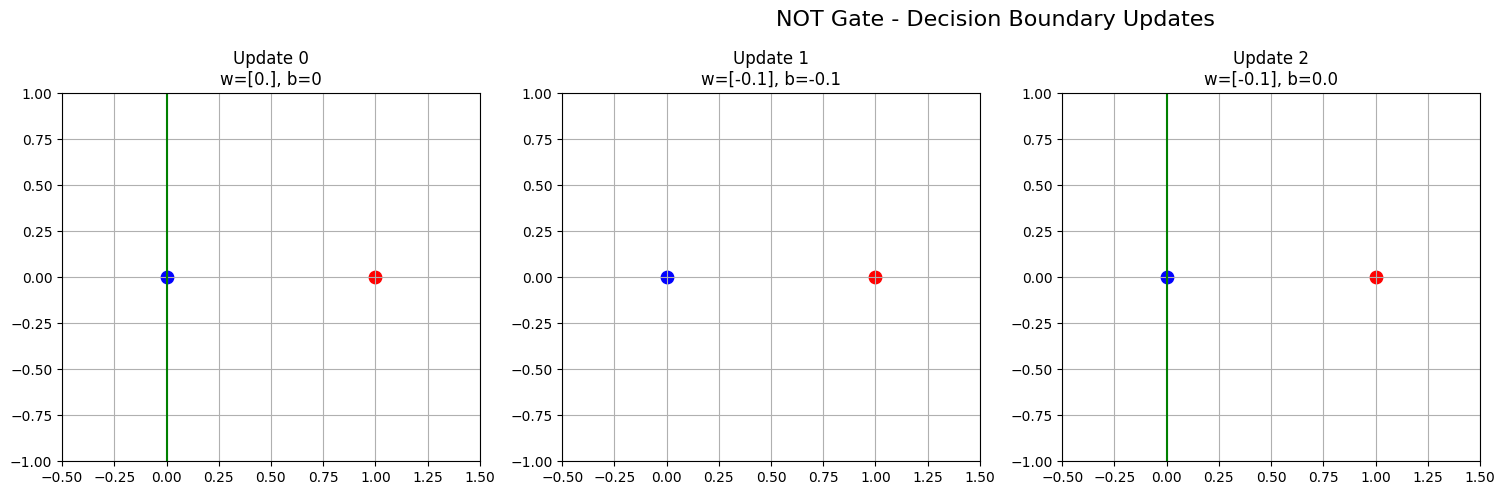


Conclusion:
AND, OR and NOT gates are linearly separable.
Therefore the perceptron learning algorithm converges.
A single decision boundary is sufficient to classify them correctly.


In [9]:
#additional tasks

import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    return 1 if x >= 0 else 0


def train_perceptron(X, y, gate_name,
                     learning_rate=0.1,
                     max_epochs=10):

    print("\n" + "=" * 60)
    print(f"{gate_name} GATE")
    print("=" * 60)

    n_features = X.shape[1]

    w = np.zeros(n_features)
    b = 0

    update_count = 0
    boundaries = []

    boundaries.append((w.copy(), b, 0))

    for epoch in range(max_epochs):

        print(f"\nEpoch {epoch+1}")

        errors = 0

        for i in range(len(X)):

            net = np.dot(X[i], w) + b

            prediction = step_function(net)

            error = y[i] - prediction

            if error != 0:

                w = w + learning_rate * error * X[i]
                b = b + learning_rate * error

                update_count += 1
                errors += 1

                print(f"\nUpdate {update_count}")
                print("Input:", X[i])
                print("Target:", y[i])
                print("Prediction:", prediction)
                print("Error:", error)

                print("Weights:", w)
                print("Bias:", b)

                boundaries.append(
                    (w.copy(), b, update_count)
                )

        if errors == 0:
            print("\nConverged!")
            break

    print("\nFinal Weights =", w)
    print("Final Bias =", b)

    plot_all_boundaries(
        X,
        y,
        boundaries,
        gate_name
    )


def plot_all_boundaries(X, y,
                        boundaries,
                        gate_name):

    num_plots = len(boundaries)

    cols = 4
    rows = (num_plots + cols - 1) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5 * cols, 5 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for idx, (weights, bias, iteration) in enumerate(boundaries):

        ax = axes[idx]

        for i in range(len(X)):

            if y[i] == 0:
                ax.scatter(
                    X[i][0],
                    0 if X.shape[1] == 1 else X[i][1],
                    color='red',
                    s=80
                )
            else:
                ax.scatter(
                    X[i][0],
                    0 if X.shape[1] == 1 else X[i][1],
                    color='blue',
                    s=80
                )

        x_vals = np.linspace(-0.5, 1.5, 100)

        if X.shape[1] == 2:

            if abs(weights[1]) > 1e-10:

                y_vals = -(weights[0] * x_vals + bias) / weights[1]

                ax.plot(
                    x_vals,
                    y_vals,
                    color='green',
                    linewidth=2
                )

            ax.set_xlim(-0.5, 1.5)
            ax.set_ylim(-0.5, 1.5)

        else:
            ax.axvline(
                x=-bias / weights[0]
                if abs(weights[0]) > 1e-10 else 0,
                color='green'
            )

            ax.set_xlim(-0.5, 1.5)
            ax.set_ylim(-1, 1)

        ax.set_title(
            f"Update {iteration}\n"
            f"w={np.round(weights,2)}, b={round(bias,2)}"
        )

        ax.grid(True)

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.suptitle(
        f"{gate_name} Gate - Decision Boundary Updates",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_or = np.array([
    0,
    1,
    1,
    1
])

train_perceptron(
    X_or,
    y_or,
    "OR"
)

X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([
    0,
    0,
    0,
    1
])

train_perceptron(
    X_and,
    y_and,
    "AND"
)

X_not = np.array([
    [0],
    [1]
])

y_not = np.array([
    1,
    0
])

train_perceptron(
    X_not,
    y_not,
    "NOT"
)

print("\nConclusion:")
print("AND, OR and NOT gates are linearly separable.")
print("Therefore the perceptron learning algorithm converges.")
print("A single decision boundary is sufficient to classify them correctly.")